--- Regression Metrics ---
MAE (Average Error): 2.74 hours
RMSE:                3.15 hours
R² Score:            -0.03


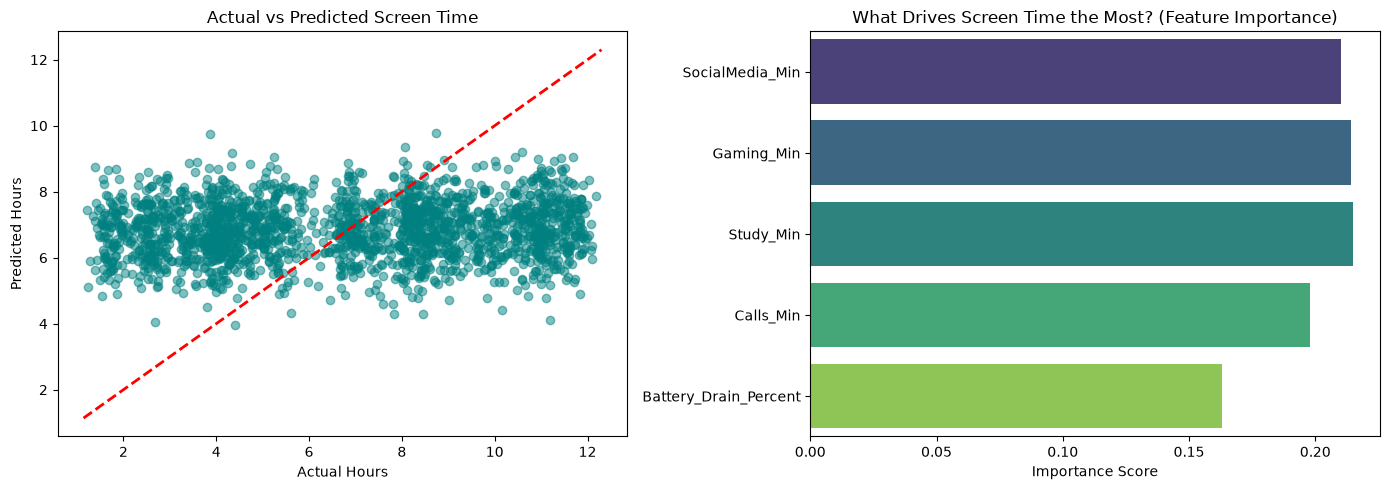

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the data
df = pd.read_csv('../data/processed/engineered_smartphone_usage.csv')

# 2. Select Features and Target (Predicting Screen Time)
potential_features = ['SocialMedia_Min', 'Gaming_Min', 'Study_Min', 'Calls_Min', 'Battery_Drain_Percent']
features = [f for f in potential_features if f in df.columns]

X = df[features]
y = df['Daily_ScreenTime_Hours']

# 3. Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Random Forest Regression Model
reg = RandomForestRegressor(random_state=42, n_estimators=100)
reg.fit(X_train, y_train)

# 5. Evaluate Model
y_pred = reg.predict(X_test)
print("--- Regression Metrics ---")
print(f"MAE (Average Error): {mean_absolute_error(y_test, y_pred):.2f} hours")
print(f"RMSE:                {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} hours")
print(f"R² Score:            {r2_score(y_test, y_pred):.2f}")

# 6. Visualize Results
plt.figure(figsize=(14, 5))

# Plot A: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Actual vs Predicted Screen Time')
plt.xlabel('Actual Hours')
plt.ylabel('Predicted Hours')

# Plot B: Feature Importance
plt.subplot(1, 2, 2)
importances = reg.feature_importances_
sns.barplot(x=importances, y=features, palette='viridis', hue=features, legend=False)
plt.title('What Drives Screen Time the Most? (Feature Importance)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()